In [1]:
from typing import List, Optional
import numpy as np
from qiskit import QuantumCircuit
from qiskit.circuit.library import RYGate, XGate, ZGate, HGate, IGate, CXGate, CZGate, SwapGate

In [2]:
class EnhancedRandomCircuit:
    def __init__(self, seed: Optional[int] = None):
        self._all_gates = {
            'x': lambda: XGate(),
            'z': lambda: ZGate(),
            'h': lambda: HGate(),
            'id': lambda: IGate(),
            'cx': lambda: CXGate(),
            'cz': lambda: CZGate(),
            'swap': lambda: SwapGate(),
            'ry': lambda theta: RYGate(theta)
        }
        self._single_qubit = ['x', 'z', 'h', 'id', 'ry']
        self._two_qubit = ['cx', 'cz', 'swap']
        self._with_parameters = ['ry']

        self._rng = np.random.default_rng(seed)

    def _get_angle(self) -> float:
        return float(self._rng.uniform(0, 2 * np.pi))

    def _select_target_qubits(self, num_qubits: int, num_targets: int, topology: str) -> List[int]:
        """Selects qubit targets based on sampled connectivity topology."""
        if num_targets == 1 or topology == "global" or num_qubits <= 2:
            return self._rng.choice(num_qubits, num_targets, replace=False).tolist()

        # Local / Nearest-Neighbor topology (creates sparse entanglement graphs)
        if topology == "local":
            q1 = int(self._rng.choice(num_qubits))
            # Choose adjacent qubit in a ring topology
            q2 = (q1 + int(self._rng.choice([-1, 1]))) % num_qubits
            return [q1, q2]
        
        return self._rng.choice(num_qubits, num_targets, replace=False).tolist()

    def get_random_circuit(
        self, 
        num_gates: int, 
        num_qubits: int, 
        max_layers: int = 5
    ) -> QuantumCircuit:
        qc = QuantumCircuit(num_qubits)

        # 1. Sample macro-style for this specific circuit instance
        p_two_qubit = self._rng.beta(0.5, 1.5)        # Biased toward single-qubit or two-qubit
        p_identity = self._rng.choice([0.0, 0.1, 0.3, 0.5]) # Forces active vs highly sparse qubits
        topology = self._rng.choice(["global", "local", "local"]) # Biased toward sparse spatial connectivity

        # 2. Build conditional gate probability distribution
        single_weight = (1.0 - p_two_qubit) * (1.0 - p_identity) / (len(self._single_qubit) - 1)
        
        weights = {}
        for g in self._single_qubit:
            weights[g] = p_identity if g == 'id' else single_weight
        for g in self._two_qubit:
            weights[g] = p_two_qubit / len(self._two_qubit)

        gate_names = list(weights.keys())
        gate_probs = np.array(list(weights.values()), dtype=np.float64)
        gate_probs /= np.sum(gate_probs)  # Normalize

        # 3. Distribute gates non-uniformly across layers
        num_layers = int(self._rng.integers(1, max_layers + 1))
        
        # Dirichlet distribution for non-uniform gate density per layer
        layer_splits = self._rng.dirichlet(np.ones(num_layers) * 0.5)
        gates_per_layer = self._rng.multinomial(num_gates, layer_splits)

        for l_idx, count in enumerate(gates_per_layer):
            if count == 0:
                continue

            selected_gates = self._rng.choice(gate_names, size=count, p=gate_probs)

            for g_name in selected_gates:
                n_q = 2 if g_name in self._two_qubit else 1
                pos = self._select_target_qubits(num_qubits, n_q, topology)

                gate_obj = (
                    self._all_gates[g_name](self._get_angle()) 
                    if g_name in self._with_parameters 
                    else self._all_gates[g_name]()
                )
                qc.append(gate_obj, pos, copy=False)

            if l_idx < num_layers - 1 and self._rng.random() < 0.4:
                qc.barrier()

        return qc

In [3]:
def get_random_circuit(n_qubits: int, total_gates: int) -> QuantumCircuit:
    """Thread-safe dataset generation function."""
    # Seed locally per invocation to avoid thread lock overhead while preserving thread-safety
    local_seed = np.random.randint(0, 2**31 - 1)
    rc = EnhancedRandomCircuit(seed=local_seed)

    # Vary max gates dynamically (from lightweight to full depth)
    gates = int(np.random.randint(1, max(2, total_gates + 1)))
    layers = int(np.random.randint(1, 8))

    return rc.get_random_circuit(num_gates=gates, num_qubits=n_qubits, max_layers=layers)

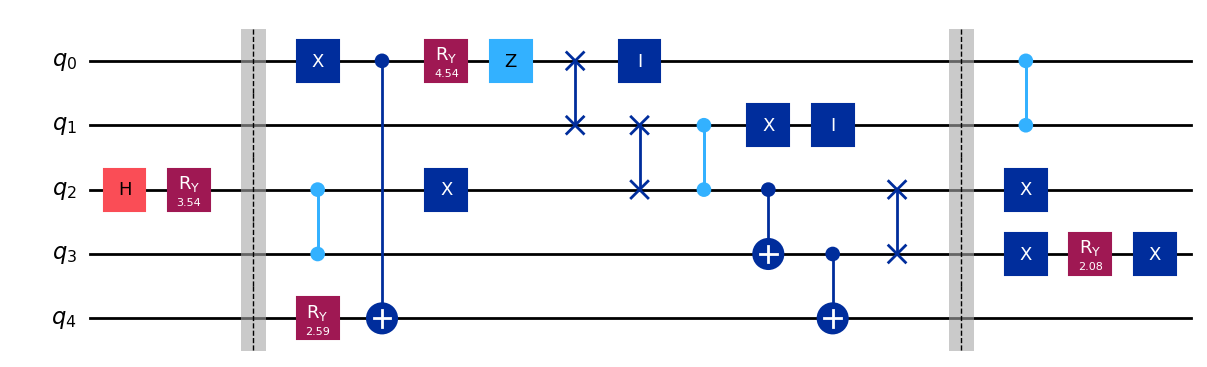

In [21]:
get_random_circuit(5,40).draw("mpl")

In [39]:
from collections import defaultdict
import hashlib

from qiskit import qasm3
from tqdm import trange
import pandas as pd

In [40]:
def test_sparsity(amount:int):
    equal = defaultdict(int)
    
    for _ in trange(amount):
        qc = get_random_circuit(5,40)
        qasm = qasm3.dumps(qc).encode('utf-8')
        hash_ = hashlib.sha256(qasm).hexdigest()
        equal[hash_] += 1
        
    d = dict(equal)
    df = pd.DataFrame({"hash":list(d.keys()), "amount":list(d.values())})
    display(df.describe())
    
    once = df[df["amount"] == 1]
    print("Amount of hashes that appeard once: ", len(once))

In [41]:
test_sparsity(10_000)

100%|████████████████████████████████████████████████████████████████████████████| 10000/10000 [00:16<00:00, 620.21it/s]


,amount
count,9855.000000
mean,1.014713
std,0.260144
min,1.000000
25%,1.000000
50%,1.000000
75%,1.000000
max,10.000000


Amount of hashes that appeard once:  9804


In [42]:
test_sparsity(30_000)

100%|████████████████████████████████████████████████████████████████████████████| 30000/30000 [00:48<00:00, 614.56it/s]


,amount
count,29401.000000
mean,1.020373
std,0.522058
min,1.000000
25%,1.000000
50%,1.000000
75%,1.000000
max,34.000000


Amount of hashes that appeard once:  29262
